<a href="https://colab.research.google.com/github/JanneWald/CS3960/blob/main/HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Part 1: Load/Analyze Data

##What is your dataset? Please describe your dataset and where you got it

I am using 2 datasets.
The first is a Kaggle dataset from Dr. Petro Ivaniuk called
[Football - FIFA World Cup, 1930 - 2022](https://www.kaggle.com/datasets/piterfm/fifa-football-world-cup)
It has 3 datafiles:
1. A list of all matches in the FIFA world cup from 1930 - 2022 with stats about them
2. Fifa ranking for all teams starting 2022 Qatari World Cup
3. A list of all world cups and some stats about them

**It was missing elo for all the matches however**

So I used second dataset that had them which I had to **scrape** from [eloratings](http://eloratings.net).

They have data for every match played for all global teams. I made a script in embedium but it was slow and hard to work with since the data wasn't in a nice http table.

Instead, I used the network console and found their api endpoint to get their tsv files. Now all I have to do is download all their tsv's and systematically add all the elo ratings for every game to the previous matches.




##Load your dataset / Implement your dataloader

In [ ]:
# TODO - load your dataset and set up your dataloader
# If applicable, please include your data with your final submission
# along with instructions for how to load it

# TODO - if not already done, please make a train/val/test split of your dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset (make sure the CSV is in your Colab files)
ranking = pd.read_csv('/content/fifa_ranking_2022-10-06.csv')
matches = pd.read_csv('/content/matches_1930_2022.csv')
wc = pd.read_csv('/content/world_cup.csv')

print("Dataset Loaded!")
print(f"Total World Cup matches: {len(matches)}")
ranking.head()
wc.head()
matches.head()

Dataset Loaded!
Total World Cup matches: 964


,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,away_manager,away_captain,Attendance,Venue,Officials,Round,Date,Score,Referee,Notes,Host,Year,home_goal,away_goal,home_goal_long,away_goal_long,home_own_goal,away_own_goal,home_penalty_goal,away_penalty_goal,home_penalty_miss_long,away_penalty_miss_long,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,Didier Deschamps,Hugo Lloris,88966,"Lusail Iconic Stadium, Lusail",Szymon Marciniak (Referee) · Paweł Sokolnicki ...,Final,2022-12-18,(4) 3–3 (2),Szymon Marciniak,Argentina won on penalty kicks following extra...,Qatar,2022,Ángel Di María · 36|Lionel Messi · 108,Kylian Mbappé · 81,['36&rsquor;|2:0|Ángel Di María|Assist:|Alexis...,['81&rsquor;|2:2|Kylian Mbappé|Assist:|Marcus ...,NaN,NaN,Lionel Messi (P) · 23,Kylian Mbappé (P) · 80|Kylian Mbappé (P) · 118,NaN,NaN,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...",NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,Hoalid Regragui,Hakim Ziyech,44137,"Khalifa International Stadium, Doha",Abdulrahman Ibrahim Al Jassim (Referee) · Tale...,Third-place match,2022-12-17,2–1,Abdulrahman Ibrahim Al Jassim,NaN,Qatar,2022,Joško Gvardiol · 7|Mislav Oršić · 42,Achraf Dari · 9,['7&rsquor;|1:0|Joško Gvardiol|Assist:|Ivan Pe...,['9&rsquor;|1:1|Achraf Dari'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,Hoalid Regragui,Romain Saïss,68294,"Al Bayt Stadium, Al Khor",César Arturo Ramos (Referee) · Alberto Morín (...,Semi-finals,2022-12-14,2–0,César Arturo Ramos,NaN,Qatar,2022,Theo Hernández · 5|Randal Kolo Muani · 79,NaN,"['5&rsquor;|1:0|Theo Hernández', '79&rsquor;|2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,Zlatko Dalić,Luka Modrić,88966,"Lusail Iconic Stadium, Lusail",Daniele Orsato (Referee) · Ciro Carbone (AR1) ...,Semi-finals,2022-12-13,3–0,Daniele Orsato,NaN,Qatar,2022,Julián Álvarez · 39|Julián Álvarez · 69,NaN,"['39&rsquor;|2:0|Julián Álvarez', '69&rsquor;|...",NaN,NaN,NaN,Lionel Messi (P) · 34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,Fernando Santos,Pepe,44198,"Al Thumama Stadium, ath-Thumāma",Facundo Tello (Referee) · Ezequiel Brailovsky ...,Quarter-finals,2022-12-10,1–0,Facundo Tello,NaN,Qatar,2022,Youssef En-Nesyri · 42,NaN,['42&rsquor;|1:0|Youssef En-Nesyri|Assist:|Yah...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [ ]:
# Master correction dictionary (expandable)
name_corrections = {
    'china pr': 'China',
    'czech republic': 'Czechia',
    'czechoslovakia': 'Czechia',
    'fr yugoslavia': 'Serbia',
    'germany dr': 'Germany',
    'ir iran': 'Iran',
    'korea dpr': 'North Korea',
    'korea republic': 'South Korea',
    'republic of ireland': 'Ireland',
    'soviet union': 'Russia',
    'türkiye': 'Turkey',
    'west germany': 'Germany',
    'zaire': 'Democratic Republic of Congo',
    'dr congo':'Democratic Republic of Congo'
}


# Remove these permanently
remove_teams = [
    "dutch east indies",
    "serbia and montenegro",
    "yugoslavia",
    "côte d'ivoire",  # if no Elo history exists
    "east germany",
    "saarland"
]

def clean_team_name(name):
    name = name.strip()

    lower_name = name.lower()
    if lower_name in remove_teams:
        return None

    if lower_name in name_corrections:
        return name_corrections[lower_name]

    # Standardize capitalization
    lowercase_words = {'and', 'of', 'the'}
    parts = name.title().split()

    cleaned = []
    for i, w in enumerate(parts):
        wl = w.lower()
        if i > 0 and wl in lowercase_words:
            cleaned.append(wl)
        else:
            cleaned.append(w.capitalize())

    return " ".join(cleaned)

    # Standardize casing
    return name

def clean_match_team_columns(df):
    df['home_team'] = df['home_team'].apply(clean_team_name)
    df['away_team'] = df['away_team'].apply(clean_team_name)

    # Remove matches with unknown or removed teams
    df = df.dropna(subset=['home_team', 'away_team'])
    return df

# Apply cleaning
matches_clean = clean_match_team_columns(matches.copy())

print("Before:", len(matches))
print("After:", len(matches_clean))

matches_clean.head()
matches = matches_clean


Before: 964
After: 919


In [ ]:
def get_result(row):
  home_goals = row['home_score']
  away_goals = row['away_score']

  if home_goals > away_goals:
    return 2 # Home Win
  if home_goals == away_goals:
    return 1 # Draw
  else:
    return 0 # Home Loss

matches['result'] = matches.apply(get_result, axis=1)

matches[['home_team', 'away_team', 'home_score', 'away_score', 'result']].head(10)

,home_team,away_team,home_score,away_score,result
0,Argentina,France,3,3,1
1,Croatia,Morocco,2,1,2
2,France,Morocco,2,0,2
3,Argentina,Croatia,3,0,2
4,Morocco,Portugal,1,0,2
5,England,France,1,2,0
6,Croatia,Brazil,1,1,1
7,Netherlands,Argentina,2,2,1
8,Morocco,Spain,0,0,1
9,Portugal,Switzerland,6,1,2


In [ ]:
train = matches[matches['Year'] < 2010]
val = matches[matches['Year'] == 2014]
test = matches[matches['Year'] == 2018]

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 669
Val: 61
Test: 64


In [ ]:
# Scrape EloRatings.net per-team match history, cache results, and merge Elo into your matches df
# Paste into Colab and run. Make sure your matches CSV is uploaded as '/content/matches_1930_2022.csv'
# Output: /content/matches_with_elo.csv
import requests
import os
from collections import Counter

def find_team_abbr(tsv_lines):
    abbr_counter = Counter()

    for line in tsv_lines:
        cols = line.split('\t')
        if len(cols) < 5:
            continue  # Skip malformed rows

        abbr_1 = cols[3]
        abbr_2 = cols[4]
        abbr_counter[abbr_1] += 1
        abbr_counter[abbr_2] += 1

    # Get the most common abbreviation and its count
    most_common_abbr, count = abbr_counter.most_common(1)[0]

    return most_common_abbr


from collections import defaultdict
team_abr = defaultdict(str)

# Get unique teams from home and away columns
home_teams = matches['home_team'].unique()
away_teams = matches['away_team'].unique()

# Combine and get unique team names overall
all_teams = set(home_teams) | set(away_teams)

# Convert to sorted list for consistency
all_teams = sorted(all_teams)

print(f"Total unique teams: {len(all_teams)}")
print(all_teams)

failed_teams = []

elo_dir = '/content/elos'
os.makedirs(elo_dir, exist_ok=True)

for team in all_teams:
    team = team.replace(' ', '_')
    url = f'http://www.eloratings.net/{team}.tsv'
    print(f"Downloading {url}")

    resp = requests.get(url)

    if resp.status_code == 200:
        # Get Abbreviation for team
        tsv_content = resp.text  # or read from saved file
        tsv_lines = tsv_content.strip().split('\n')
        abbr = find_team_abbr(tsv_lines)
        team_abr[team] = abbr

        # Save file
        with open(f"{elo_dir}/{team}.tsv", 'wb') as f:
            f.write(resp.content)
            print('Saved', abbr)
    else:
        print(f"Failed to download {url}")
        failed_teams.append(team)

print('Failed teams:')
print(failed_teams)

Total unique teams: 77
['Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cameroon', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Czechia', 'Democratic Republic of Congo', 'Denmark', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'France', 'Germany', 'Ghana', 'Greece', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Kuwait', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'North Korea', 'Northern Ireland', 'Norway', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russia', 'Saudi Arabia', 'Scotland', 'Senegal', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Togo', 'Trinidad and Tobago', 'Tunisia', 'Turkey', 'Ukraine', 'United Arab Emirates', 'United States', 'Uruguay', 'Wales']
Saved DZ
Saved AO
Saved AR
Saved AU
Saved AT
Saved BE

In [ ]:
import pandas as pd
from datetime import datetime

def load_team_elo_df(team, abbr, folder='/content/elos'):
    # Load the team's TSV into a DataFrame with parsed date column
    path = f"{folder}/{team}.tsv"
    df = pd.read_csv(path, sep='\t', header=None)
    df.head()

    # Build datetime column
    df['date_str'] = df[0].astype(str) + '-' + df[1].astype(str).str.zfill(2) + '-' + df[2].astype(str).str.zfill(2)
    #print(1)
    #print(df[[0,1,2]])
    df['date'] = pd.to_datetime(df['date_str'], errors='coerce')
    #print(df['date_str'])
    #print(df['date'])

    df['abbr_home'] = df[3]
    df['abbr_away'] = df[4]
    df['elo_home'] = df[10]
    df['elo_away'] = df[11]
    df['abbr'] = abbr  # store the team's abbreviation
    return df

def find_closest_elo(df, match_date, team_abbr, is_home):
    # Filter rows where team abbreviation matches on home or away column accordingly
    if is_home:
        relevant_rows = df[df['abbr_home'] == team_abbr]
        elo_col = 'elo_home'
    else:
        relevant_rows = df[df['abbr_away'] == team_abbr]
        elo_col = 'elo_away'

    # Filter rows where date <= match_date
    past_rows = relevant_rows[relevant_rows['date'] <= match_date]

    if past_rows.empty:
        # No prior data; maybe return NaN or some default
        return float('nan')

    # Pick the row with the max date <= match_date
    closest_row = past_rows.loc[past_rows['date'].idxmax()]

    return closest_row[elo_col]

def add_elo_ratings_to_matches(matches, team_abr, elo_folder='/content/elos'):
    # Cache loaded team dfs here to avoid reloading TSV multiple times
    team_elo_dfs = {}

    home_elo_list = []
    away_elo_list = []

    for idx, row in matches.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        #print(home_team)
        # Convert Year, Month, Day (if separate columns) to datetime
        # If you have a 'Date' column string, parse that instead
        if 'Date' in matches.columns:
            match_date = pd.to_datetime(row['Date'])
        else:
            # fallback: use Year only (you could improve this if you have month/day)
            match_date = pd.to_datetime(f"{row['Year']}-01-01")

        #print(match_date)
        # Get abbreviations
        home_abbr = team_abr.get(home_team, None)
        away_abbr = team_abr.get(away_team, None)
        print(home_abbr, away_abbr)


        if home_abbr is None or away_abbr is None:
            # Missing abbreviation → can't get elo
            home_elo_list.append(float('nan'))
            away_elo_list.append(float('nan'))
            continue

        #print('Hello')

        # Load TSVs for teams if not cached
        home_team = home_team.replace(' ', '_')
        away_team = away_team.replace(' ', '_')

        if home_team not in team_elo_dfs:
            team_elo_dfs[home_team] = load_team_elo_df(home_team, home_abbr, elo_folder)
        if away_team not in team_elo_dfs:
            team_elo_dfs[away_team] = load_team_elo_df(away_team, away_abbr, elo_folder)

        #print('Hello')

        home_elo = find_closest_elo(team_elo_dfs[home_team], match_date, home_abbr, is_home=True)
        away_elo = find_closest_elo(team_elo_dfs[away_team], match_date, away_abbr, is_home=False)

        home_elo_list.append(home_elo)
        away_elo_list.append(away_elo)

    matches['home_elo'] = home_elo_list
    matches['away_elo'] = away_elo_list

    return matches


In [ ]:
matches_with_elo = add_elo_ratings_to_matches(matches, team_abr, elo_folder='/content/elos')
matches_with_elo.to_csv('/content/matches_with_elo.csv', index=False)


AR FR
HR MA
FR MA
AR HR
MA PT
EN FR
HR BR
NL AR
MA ES
PT CH
JP HR
BR None
FR PL
EN SN
NL None
AR AU
None PT
GH UY
CM BR
YU CH
CA MA
HR BE


/tmp/ipython-input-3658934757.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date_str'], errors='coerce')
/tmp/ipython-input-3658934757.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date_str'], errors='coerce')


None DE
JP ES
AU DK
TN FR
None MX
PL AR
EC SN
NL QA
IR None
WA EN
CM YU
None GH
BR CH
PT UY
JP None
BE MA
HR CA
ES DE
TN AU
PL None
FR DK
AR MX
WA IR
QA SN
NL EC
EN None
CH CM
UY None
PT GH
BR YU
MA HR
DE JP
ES None
BE CA
AR None
DK TN
MX PL
FR AU
EN IR
SN NL
None WA
QA EC
FR HR
BE EN
HR EN
FR BE
SE EN
SU HR
UY FR
BR BE
SE CH
CO EN
BR MX
BE JP
ES SU
HR DK
FR AR
UY PT
JP PL
SN CO
EN BE
PA TN
None DE
MX SE
CH None
YU BR
AU PE
DK FR
IS HR
NG AR


/tmp/ipython-input-3658934757.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date_str'], errors='coerce')


None EG
UY SU
ES MA
IR PT
EN PA
JP SN
PL CO
BE TN
None MX
DE SE
BR None
NG IS
YU CH
DK AU
FR PE
AR HR
PT MA
UY None
IR ES
CO JP
PL SN
SU EG
SE None
BE PA
TN EN
None YU
DE MX
BR CH
FR AU
AR IS
PE DK
HR NG
EG UY
MA IR
PT ES
SU None
DE AR
BR NL
NL AR
BR DE
AR BE
NL None
FR DE
BR CO
AR CH
BE None
FR NG
DE DZ
NL MX
None GR
BR CL
CO UY
None DE
PT GH
None BE
DZ SU
None IR
NG AR
HN CH
EC FR
None EN
IT UY
JP CO
AU ES
NL CL
HR MX
CM BR
BE SU
None DZ
None PT
AR IR
DE GH
NG None
IT None
CH FR
HN EC
UY EN
JP GR
AU NL
ES CL
CM HR
BE DZ
BR MX
SU None
DE PT
IR NG
GH None
CH EC
FR HN
AR None
CO GR
UY None
EN IT
MX CM
ES NL
CL AU
BR HR
NL ES
UY DE
DE ES
UY NL
AR DE
PY ES
NL BR
UY GH
PY JP
ES PT
NL SK
BR CL
DE EN
AR MX
UY None
None GH
PT BR
CL ES
CH HN
PY None
SK IT
DK JP
CM NL
SI EN
None DZ
GH DE
AU YU
MX UY
FR None
NG None
GR AR
PT None
CL CH
ES HN
SK PY
IT None
NL JP
GH AU
CM DK
DE YU
SI None
EN DZ
AR None
GR NG
FR MX
HN CL
ES CH
None UY
None SK
BR None
NL DK
JP CM
IT PY
DZ SI
YU GH
DE AU
None GR
AR N

/tmp/ipython-input-3658934757.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date_str'], errors='coerce')


None TG
FR CH
BR HR
AU JP
None CS
IT GH
MX IR
AO PT
EN PY
None SE
DE None
PL EC
DE BR
None TR
BR TR
DE None
ES None
SN TR
EN BR
DE None
JP TR
None IT
MX None
BR BE
SE SN
ES IE
DE PY
DK EN
TN JP
BE SU
PT None
PL None
None BR
TR CN
MX IT
EC HR
SE AR
NG EN
None ES
SI PY
DK FR
SN UY
None IE
CM DE
None None
TN BE
PT PL
MX EC
None TR
JP SU
None SI
IT HR
BR CN
SE NG
ES PY
AR EN
DK SN
CM None
FR UY
SU TN
None PT
DE IE
CN None
JP BE
None PL
HR MX
BR TR
IT EC
AR NG
PY None
EN SE
ES SI
IE CM
UY DK
DE None
FR SN
BR FR
NL HR
FR HR
BR NL
NL AR
DE HR
IT FR
BR DK
RO HR
AR EN
DE MX
NL YU
FR PY
NG DK
IT NO
BR CL
AR HR
JP JM
RO TN
CO EN
NL MX
BE None
None YU
DE IR
None None
FR DK
ES BG
NG PY
IT AT
CL CM
BR NO
SQ MA
CO TN
RO EN
DE YU
AR JM
None IR
JP HR
BE MX
NL None
NG BG
ES PY
None DK
FR None
CL AT
IT CM
SQ NO
BR MA
EN TN
RO CO
DE None
AR JP
YU IR
JM HR
ES NG
None MX
NL BE
PY BG
None DK
FR None
IT CL
CM AT
BR SQ
MA NO
BR IT
SE BG
BG IT
SE BR
BG DE
RO SE
IT ES
NL BR
NG IT
MX BG
NL IE
BR None
None SE
RO A

##  Dataset Analyis Statistics

### Most Common Teams

In [ ]:
df = matches_with_elo.copy()  # or matches

# Get the 10 most common teams appearing as home/away
team_counts = (
    pd.concat([df['home_team'], df['away_team']])
    .value_counts()
)

top10_teams = team_counts.head(10).index.tolist()
print("Top 10 Teams:", top10_teams)

Top 10 Teams: ['Germany', 'Brazil', 'Argentina', 'Italy', 'England', 'France', 'Spain', 'Mexico', 'Uruguay', 'Netherlands']


### Elo Ratings of Matches over Time

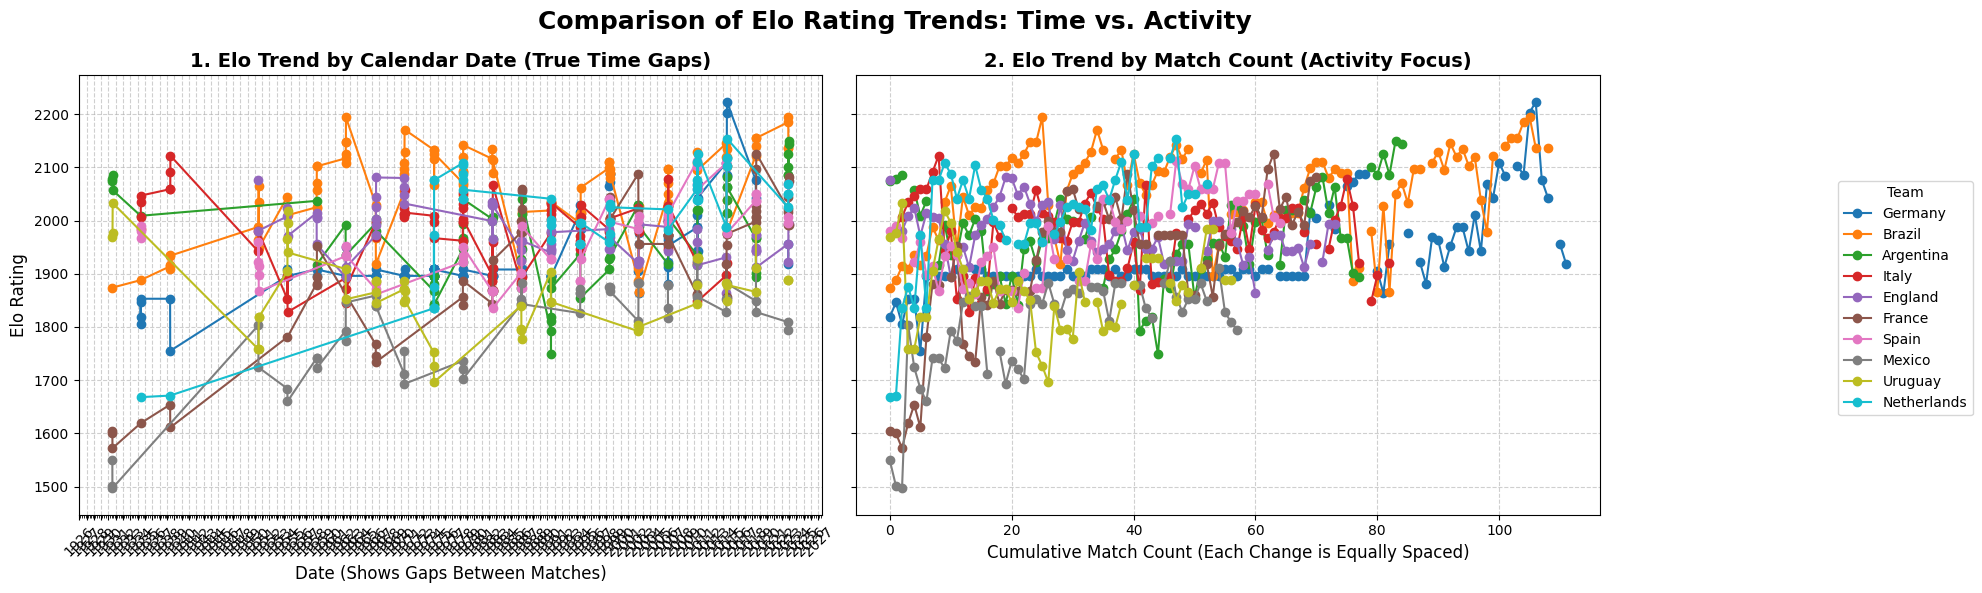

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # This is the import needed for mdates


# Filter to only those teams
chart_df = matches_with_elo[
    (matches_with_elo['home_team'].isin(top10_teams)) |
    (matches_with_elo['away_team'].isin(top10_teams))
].copy()

# Convert Date to datetime objects, forcing any unparseable dates to NaT (Not a Time)
matches_with_elo['Date'] = pd.to_datetime(matches_with_elo['Date'], errors='coerce')

# Crucial addition: Remove any rows where the date could not be parsed and is now NaT
matches_with_elo = matches_with_elo.dropna(subset=['Date'])

# Simulate the user's filtering step to get chart_df
chart_df = matches_with_elo[
    (matches_with_elo['home_team'].isin(top10_teams)) |
    (matches_with_elo['away_team'].isin(top10_teams))
].copy()

# --- 2. DATA TRANSFORMATION FOR PLOTTING (No changes needed here) ---

def prepare_elo_time_series(df, relevant_teams):
    """
    Transforms match-based Elo data into a long-format time series suitable for plotting.

    It extracts the Date, Team name, and Elo score for every team in every match
    that is part of the relevant_teams set.
    """
    elo_records = []

    for _, row in df.iterrows():
        date = row['Date']

        # Record Home Team Elo if it's a team we care about
        if row['home_team'] in relevant_teams:
            elo_records.append({
                'Date': date,
                'Team': row['home_team'],
                'Elo': row['home_elo']
            })

        # Record Away Team Elo if it's a team we care about
        if row['away_team'] in relevant_teams:
            elo_records.append({
                'Date': date,
                'Team': row['away_team'],
                'Elo': row['away_elo']
            })

    # Create the final time series DataFrame
    elo_ts_df = pd.DataFrame(elo_records)

    # Crucial step: Sort by Date to ensure correct chronological plotting
    elo_ts_df = elo_ts_df.sort_values(by='Date').reset_index(drop=True)

    return elo_ts_df

# Run the transformation on your completed chart_df
elo_time_series = prepare_elo_time_series(chart_df, top10_teams)


# --- 3. PLOTTING FUNCTION (Modified to create two subplots) ---

def plot_elo_comparison(df, teams_to_plot):
    """
    Plots the Elo rating over time for the specified teams in two subplots:
    1. X-axis by Calendar Date (shows true gaps).
    2. X-axis by Match Index (compresses time gaps for activity focus).
    """
    # Create a figure with two subplots side-by-side, sharing the Y-axis
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

    # Calculate global Elo range for consistent Y-axis
    if not df.empty:
        min_elo = df['Elo'].min() - 50
        max_elo = df['Elo'].max() + 50
        y_lim = (min_elo, max_elo)
    else:
        # Default limits if DataFrame is empty
        y_lim = (1400, 1800)

    # Plot each team's line on both axes
    for team in teams_to_plot:
        # Filter data for the current team and sort it chronologically
        team_data = df[df['Team'] == team].sort_values(by='Date')

        # Define X-axis as a simple index (match count) for non-linear time spacing
        match_index = range(len(team_data))

        # --- PLOT 1: Calendar Date (True Time Series) ---
        ax1.plot(
            team_data['Date'],
            team_data['Elo'],
            label=team,
            marker='o',
            linestyle='-'
        )

        # --- PLOT 2: Match Index (Activity Series) ---
        ax2.plot(
            match_index,
            team_data['Elo'],
            label=team,
            marker='o',
            linestyle='-'
        )

    # --- AXIS 1: Calendar Date Formatting ---
    ax1.set_title('1. Elo Trend by Calendar Date (True Time Gaps)', fontsize=14, weight='bold')
    ax1.set_xlabel('Date (Shows Gaps Between Matches)', fontsize=12)
    ax1.set_ylabel('Elo Rating', fontsize=12)

    # Apply date formatting for readability (Yearly major ticks, 3-month minor ticks)
    date_format = mdates.DateFormatter('%Y')
    ax1.xaxis.set_major_formatter(date_format)
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    ax1.tick_params(axis='x', rotation=45)

    # --- AXIS 2: Match Index Formatting ---
    ax2.set_title('2. Elo Trend by Match Count (Activity Focus)', fontsize=14, weight='bold')
    ax2.set_xlabel('Cumulative Match Count (Each Change is Equally Spaced)', fontsize=12)
    # Y-label is automatically shared/omitted due to sharey=True

    # --- Shared Aesthetics and Final Touches ---
    ax1.set_ylim(y_lim)
    ax2.set_ylim(y_lim)

    ax1.grid(axis='both', linestyle='--', alpha=0.6)
    ax2.grid(axis='both', linestyle='--', alpha=0.6)

    # Use a single legend for the entire figure
    fig.legend(
        labels=teams_to_plot,
        title='Team',
        bbox_to_anchor=(1.02, 0.5), # Position it to the right of the second plot
        loc='center left'
    )

    fig.suptitle('Comparison of Elo Rating Trends: Time vs. Activity', fontsize=18, weight='bold')

    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make room for legend
    plt.show()

# Execute the plotting function
if not elo_time_series.empty:
    # UPDATED function call to the new name
    plot_elo_comparison(elo_time_series, top10_teams)
else:
    print("No data found for the specified top teams to plot.")


# Part 2: Literature Review

### Paper 1
Citation
```txt
Albert Wong, Eugene Li, Huan Le, Gurbir Bhangu, Suveer Bhatia,
A predictive analytics framework for forecasting soccer match outcomes using machine learning models,
Decision Analytics Journal,
Volume 14,
2025,
100537,
ISSN 2772-6622,
https://doi.org/10.1016/j.dajour.2024.100537.
(https://www.sciencedirect.com/science/article/pii/S2772662224001413)
```

This was one of the first papers I read. Their goal was to build a predictive model for forcasting soccer matches like myself but in the English Premier League (EPL)

They used historical match results, **but also** incorporated additional features: publicly available game results, weather data, and their own metric of team fatigue and momentum.

They thought these extra features would improve predictive performance beyond “just results-based” features.

They compared many models.
`logistic regression (LR), random forest (RF), support vector machine (SVM), and XGboost (XGB)`

As well as a LightGBM and CNN model.

According to the paper, their models “showed promise compared to those derived from odds given by major bookmakers.”
ScienceDirect

### Paper 2
Citation
```text
Jain, Sarika & Tiwari, Ekansh & Sardar, Prasanjit. (2021).
Soccer Result Prediction Using Deep Learning and Neural Networks.
10.1007/978-981-15-9509-7_57.
(https://www.researchgate.net/publication/349272309_Soccer_Result_Prediction_Using_Deep_Learning_and_Neural_Networks)
```
Their goal was also to build a system that predicts the outcome of soccer matches using deep learning / neural network techniques.

They also used a dataset of professional soccer matches covering many seasons.
The model they build was based on an RNN, with LSTM cells to handle sequential data and potentially capture temporal dependencies across matches.

They included “match- and player-related information captured by a STATS platform in a time slot of 15 minutes”. So they had high-granularity data rather than just final match-level stats.

Their model reportedly achieved “over 80% accuracy” in predicting match winners, announcing they were potentially one of the first to achieve such a high accuracy.


# Part 3: Implement networks in PyTorch

Note of warning here: Depending on how easily you can allocate GPU resources, you may want to make your network much shallower so that you can train it more easily
Aim to have one gradient update take no more than a few seconds
May also want to reduce the number of training steps if training is too slow

Accuracy: 0.5460526315789473
              precision    recall  f1-score   support

          -1      0.480     0.343     0.400        35
           0      0.000     0.000     0.000        40
           1      0.559     0.922     0.696        77

    accuracy                          0.546       152
   macro avg      0.346     0.422     0.365       152
weighted avg      0.394     0.546     0.445       152



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

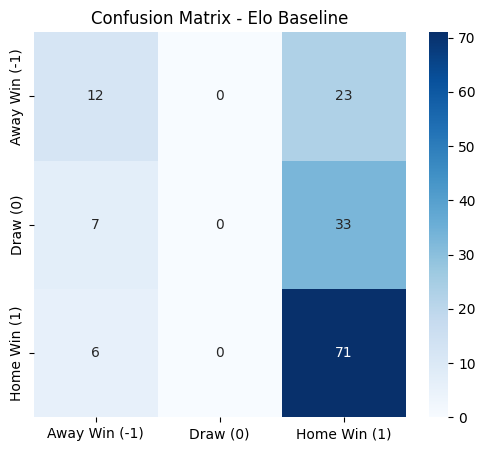

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Copy to avoid accidental mutation
df = matches_with_elo.copy()

# Clean NaNs from Elo
df = df.dropna(subset=['home_elo', 'away_elo'])

# Feature Engineering
df['elo_diff'] = df['home_elo'] - df['away_elo']

df['venue_home'] = (df['home_team'] == df['Host']).astype(int)
df['venue_away'] = (df['away_team'] == df['Host']).astype(int)
df['venue_neutral'] = 1 - (df['venue_home'] | df['venue_away'])

# Define X, y
features = ['home_elo', 'away_elo', 'elo_diff', 'venue_home', 'venue_away', 'venue_neutral']
X = df[features]
y = df['result']

# Split train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

# Baseline model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues",
            xticklabels=["Away Win (-1)", "Draw (0)", "Home Win (1)"],
            yticklabels=["Away Win (-1)", "Draw (0)", "Home Win (1)"])
plt.title("Confusion Matrix - Elo Baseline")
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch

# Step 1: Copy dataset and drop NaNs
df = matches_with_elo.copy()
df = df.dropna(subset=['home_elo', 'away_elo'])

# Step 2: Feature engineering (same as logistic regression)
df['elo_diff'] = df['home_elo'] - df['away_elo']

df['venue_home'] = (df['home_team'] == df['Host']).astype(int)
df['venue_away'] = (df['away_team'] == df['Host']).astype(int)
df['venue_neutral'] = 1 - (df['venue_home'] | df['venue_away'])

# Step 3: Select features and target
features = ['home_elo', 'away_elo', 'elo_diff', 'venue_home', 'venue_away', 'venue_neutral']
X = df[features]
y = df['result']

# Step 4: Split into train/val/test sets with stratification for balanced classes
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Step 5: Convert to PyTorch tensors with correct dtype
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Check shapes
print(f"Train set: {X_train_tensor.shape}, {y_train_tensor.shape}")
print(f"Validation set: {X_val_tensor.shape}, {y_val_tensor.shape}")
print(f"Test set: {X_test_tensor.shape}, {y_test_tensor.shape}")


Train set: torch.Size([605, 6]), torch.Size([605])
Validation set: torch.Size([76, 6]), torch.Size([76])
Test set: torch.Size([76, 6]), torch.Size([76])


In [ ]:
# TODO - implement your PyTorch Module
import torch
import torch.nn as nn
import torch.nn.functional as F

class MatchPredictorNN(nn.Module):
    def __init__(self, input_dim):
        super(MatchPredictorNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)  # first hidden layer
        self.fc2 = nn.Linear(64, 32)         # second hidden layer
        self.output_layer = nn.Linear(32, 3) # output layer: 3 classes

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.output_layer(x)  # raw scores (logits)
        return logits


In [ ]:
print(device)
model = 'a' # idk this actually helps cleans the variable in collab
model = MatchPredictorNN(input_dim=6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

cuda


In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import torch.nn as nn
import torch

# Setup DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)

num_epochs = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import matplotlib.pyplot as plt

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    train_loss = 0
    train_preds = []
    train_targets = []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        train_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        train_targets.extend(y_batch.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_targets, train_preds)

    # --- Validation ---
    model.eval()
    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            val_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            val_targets.extend(y_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(val_targets, val_preds)

    # Store for plotting
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/50 | Train Loss: 10.2538, Train Acc: 0.3983 | Val Loss: 4.6041, Val Acc: 0.2500
Epoch 2/50 | Train Loss: 3.4454, Train Acc: 0.4446 | Val Loss: 3.1377, Val Acc: 0.2500
Epoch 3/50 | Train Loss: 2.1372, Train Acc: 0.4959 | Val Loss: 1.3983, Val Acc: 0.5526
Epoch 4/50 | Train Loss: 1.6809, Train Acc: 0.5256 | Val Loss: 1.5878, Val Acc: 0.5526
Epoch 5/50 | Train Loss: 1.3103, Train Acc: 0.5504 | Val Loss: 1.6519, Val Acc: 0.4737
Epoch 6/50 | Train Loss: 1.2293, Train Acc: 0.5421 | Val Loss: 0.9543, Val Acc: 0.5658
Epoch 7/50 | Train Loss: 1.3596, Train Acc: 0.4826 | Val Loss: 0.9403, Val Acc: 0.5395
Epoch 8/50 | Train Loss: 1.1731, Train Acc: 0.5736 | Val Loss: 1.0926, Val Acc: 0.5921
Epoch 9/50 | Train Loss: 1.0235, Train Acc: 0.5438 | Val Loss: 0.9836, Val Acc: 0.5921
Epoch 10/50 | Train Loss: 1.0620, Train Acc: 0.5223 | Val Loss: 1.2446, Val Acc: 0.3684
Epoch 11/50 | Train Loss: 1.0984, Train Acc: 0.5273 | Val Loss: 1.2370, Val Acc: 0.6053
Epoch 12/50 | Train Loss: 1.1120, Train 

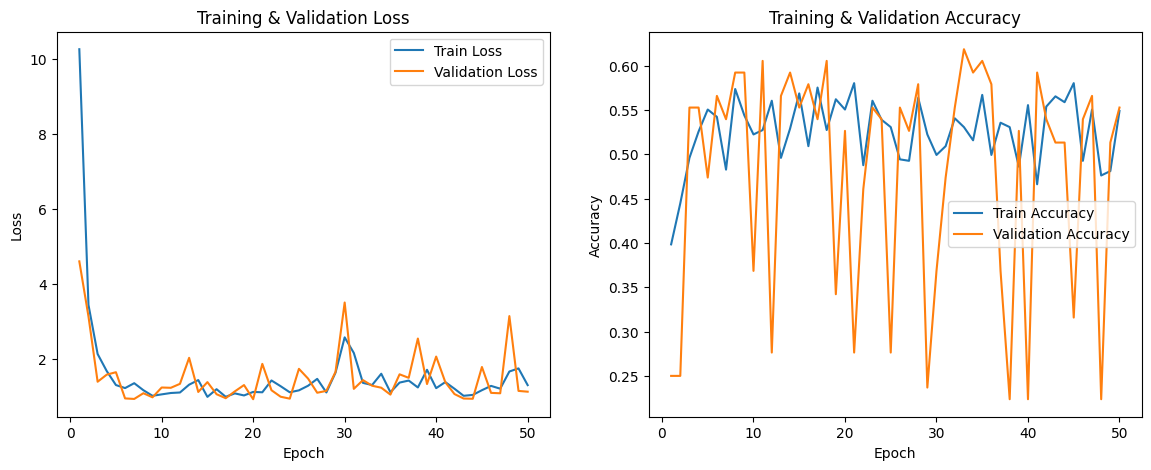

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()


Hint: look at earlier homeworks / resuse code from those to help you here

# Part 4: Run Hyperparameter Experiments

In [ ]:
# TODO - perform hyperparameter grid searches and plot accuracies

In [ ]:
# TODO - perform other experiments and plot accuracies

In [ ]:
# TODO - calculate the final test accuracy

TODO - Explain your experiments above. See assignment doc for more details.